In [1]:
import sys

sys.path.append("..")

import copy
import json
import random
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    f1_score,
    recall_score,
)
from sklearn.model_selection import StratifiedGroupKFold
from torch.utils.data import DataLoader, WeightedRandomSampler

from src.dataset.modules.augment_flow import AugmentFlow
from src.dataset.modules.behavioral_features import BehavioralFeatures
from src.dataset.modules.compose import Compose
from src.dataset.modules.flow_roi_dataset import FlowROIDataset
from src.dataset.modules.temporal_transforms import PadAndMask

# Dataset
from src.dataset.modules.window_selector import ApexWindowDetector, WindowSelector

# Evaluator & Plotter
from src.evaluator.modules import FeatureExtractor, MetricsEvaluator

# Model
from src.models.modules.cnn_bi_lstm_mha.cnn_bi_lstm_mha import CNN_BiLSTM_MHA
from src.plotter.modules import (
    ClassificationReportDisplay,
    ConfusionMatrixPlotter,
    HistoryPlotter,
    ROCCurvePlotter,
    TSNEPlotter,
)

# Config
MAX_SEQ_LEN_CAP = 512
MAX_SEQ_LEN_PERCENTILE = 95
MAX_SEQ_LEN = MAX_SEQ_LEN_CAP
AUG_SCALE_RANGE = (0.95, 1.05)
AUG_NOISE_STD = 0.005
AUG_TEMPORAL_MASK_PROB = 0.0
AUG_TEMPORAL_MASK_RATIO = (0.0, 0.0)
DETECTOR_PERCENTILE = 95
DETECTOR_PROMINENCE = 0.5
DETECTOR_METRICS_MAX_ROWS = 200  # set None untuk scan penuh
THRESHOLD_METRIC = "macro_f1"  # opsi: "macro_f1" atau "bacc"
BATCH_SIZE = 8
EPOCHS = 100
LR = 2e-4
WEIGHT_DECAY = 1e-2
WARMUP_EPOCHS = 10
PATIENCE = 40
MIN_DELTA = 0.002
EMA_ALPHA = 0.3
LABEL_SMOOTH = 0.15
N_TTA = 8
USE_TTA_INFERENCE = True
SEED = 42
PHASES = ["onset", "apex"]
TARGET_NAMES = ["Anxiety Rendah", "Anxiety Tinggi"]
ANNOTATION_PATH = Path("/home/inadio/datasets/anxiety_raw/annotations-v10-clips.csv")
CHECKPOINT_DIR = Path("./checkpoints_0405-onset-apex-behavior-cnn-bi-lstm-mha")


CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f"Device: {DEVICE}")


def find_best_threshold(y_true, y_prob, lo=0.2, hi=0.8, n_steps=121, metric="macro_f1"):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    best_thr, best_score = 0.5, -1.0
    for thr in np.linspace(lo, hi, n_steps):
        pred = (y_prob >= thr).astype(int)
        if metric == "bacc":
            score = balanced_accuracy_score(y_true, pred)
        else:
            score = f1_score(y_true, pred, average="macro", zero_division=0)
        if score > best_score:
            best_score = score
            best_thr = float(thr)
    return best_thr, float(best_score)


def tta_predict_positive_proba(model, batch_x, batch_mask, n_tta=N_TTA):
    probs = 0.0
    for _ in range(n_tta):
        scale = torch.empty(batch_x.size(0), device=batch_x.device).uniform_(0.93, 1.07)
        scale = scale.view(-1, *([1] * (batch_x.ndim - 1)))
        x_aug = batch_x * scale
        x_aug = x_aug + torch.randn_like(x_aug) * 0.02
        logits = model(x_aug, mask=batch_mask)
        probs = probs + torch.softmax(logits, dim=1)[:, 1]
    return probs / float(n_tta)


def evaluate_model(model, loader, criterion, threshold=0.5, use_tta=False, n_tta=N_TTA):
    model.eval()
    total_loss, total_n = 0.0, 0
    y_true, y_prob = [], []
    with torch.inference_mode():
        for batch_x, batch_y, batch_mask in loader:
            batch_x = batch_x.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            batch_mask = batch_mask.to(DEVICE)
            logits = model(batch_x, mask=batch_mask)
            total_loss += criterion(logits, batch_y).item() * batch_x.size(0)
            total_n += batch_y.size(0)
            if use_tta:
                pos_prob = tta_predict_positive_proba(
                    model, batch_x, batch_mask, n_tta=n_tta
                )
            else:
                pos_prob = torch.softmax(logits, dim=1)[:, 1]
            y_true.extend(batch_y.cpu().numpy().tolist())
            y_prob.extend(pos_prob.cpu().numpy().tolist())
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_pred = (y_prob >= float(threshold)).astype(int)
    loss = total_loss / max(total_n, 1)
    acc = float((y_pred == y_true).mean()) if total_n > 0 else 0.0
    return loss, acc, y_true, y_pred, y_prob




Device: cuda


In [2]:
def collate_fn(batch):
    xs = torch.stack([item.x for item in batch])
    ys = torch.stack([item.y for item in batch])
    if batch[0].mask is not None:
        masks = torch.stack([item.mask for item in batch])
    else:
        masks = torch.zeros(len(batch), xs.shape[-1], dtype=torch.bool)
    return xs, ys, masks




In [3]:
feature_transform = BehavioralFeatures()

df = pd.read_csv(ANNOTATION_PATH)

if "npy_path" not in df.columns and "cache_path" in df.columns:
    df["npy_path"] = df["cache_path"]
if "is_valid" in df.columns:
    df = df[df["is_valid"]].copy()


def custom_sgkf_train_val_split(
    metadata_df,
    target_val_ratio: float = 0.30,
    n_splits: int = 10,
    random_state: int = 42,
):
    required_cols = {"subject_id", "label"}
    missing = required_cols - set(metadata_df.columns)
    if missing:
        raise ValueError(f"metadata_df missing columns: {sorted(missing)}")

    if not (0.0 < target_val_ratio < 1.0):
        raise ValueError("target_val_ratio must be in (0, 1)")

    work_df = metadata_df.reset_index(drop=True).copy()
    n_samples = len(work_df)
    if n_samples == 0:
        raise ValueError("metadata_df is empty")

    y = work_df["label"].to_numpy()
    groups = work_df["subject_id"].to_numpy()

    sgkf = StratifiedGroupKFold(
        n_splits=n_splits, shuffle=True, random_state=random_state
    )
    fold_val_indices = []
    for _, val_idx in sgkf.split(np.zeros(n_samples), y, groups=groups):
        fold_val_indices.append(np.asarray(val_idx, dtype=int))

    n_val_folds = int(round(target_val_ratio * n_splits))
    n_val_folds = max(1, min(n_splits - 1, n_val_folds))

    label_order = sorted(pd.unique(work_df["label"]))
    full_dist = (
        work_df["label"]
        .value_counts(normalize=True)
        .reindex(label_order, fill_value=0.0)
        .to_numpy(dtype=float)
    )

    all_idx = np.arange(n_samples, dtype=int)
    n_subjects_total = max(work_df["subject_id"].nunique(), 1)
    best = None

    for fold_combo in combinations(range(n_splits), n_val_folds):
        val_idx = np.unique(np.concatenate([fold_val_indices[i] for i in fold_combo]))
        if val_idx.size == 0 or val_idx.size >= n_samples:
            continue

        train_mask = np.ones(n_samples, dtype=bool)
        train_mask[val_idx] = False
        train_idx = all_idx[train_mask]
        if train_idx.size == 0:
            continue

        val_df_candidate = work_df.iloc[val_idx]
        train_df_candidate = work_df.iloc[train_idx]

        val_ratio = float(val_idx.size / n_samples)
        ratio_err = abs(val_ratio - target_val_ratio)

        val_dist = (
            val_df_candidate["label"]
            .value_counts(normalize=True)
            .reindex(label_order, fill_value=0.0)
            .to_numpy(dtype=float)
        )
        class_drift = float(np.abs(val_dist - full_dist).sum())

        val_subject_ratio = float(
            val_df_candidate["subject_id"].nunique() / n_subjects_total
        )
        group_ratio_err = abs(val_subject_ratio - target_val_ratio)

        score = ratio_err + 0.5 * class_drift + 0.2 * group_ratio_err
        tie_breaker = (ratio_err, class_drift, group_ratio_err, fold_combo)

        if best is None or (score, tie_breaker) < (best["score"], best["tie_breaker"]):
            best = {
                "score": score,
                "tie_breaker": tie_breaker,
                "fold_combo": fold_combo,
                "train_idx": train_idx,
                "val_idx": val_idx,
                "train_df": train_df_candidate.copy(),
                "val_df": val_df_candidate.copy(),
            }

    if best is None:
        raise RuntimeError("Could not find a valid fold combination for split")

    train_df = best["train_df"]
    val_df = best["val_df"]
    test_df = work_df.iloc[0:0].copy()

    train_dist = (
        train_df["label"]
        .value_counts(normalize=True)
        .reindex(label_order, fill_value=0.0)
        .to_numpy(dtype=float)
    )
    val_dist = (
        val_df["label"]
        .value_counts(normalize=True)
        .reindex(label_order, fill_value=0.0)
        .to_numpy(dtype=float)
    )

    diagnostics = {
        "selected_val_folds": list(best["fold_combo"]),
        "target_val_ratio": float(target_val_ratio),
        "val_ratio": float(len(val_df) / n_samples),
        "train_ratio": float(len(train_df) / n_samples),
        "class_drift_l1": float(np.abs(val_dist - full_dist).sum()),
        "score": float(best["score"]),
        "label_order": label_order,
        "full_dist": full_dist.tolist(),
        "train_dist": train_dist.tolist(),
        "val_dist": val_dist.tolist(),
    }
    return train_df, val_df, test_df, diagnostics


train_df, val_df, test_df, split_metrics = custom_sgkf_train_val_split(
    df, target_val_ratio=0.20, n_splits=10, random_state=42
)


def _compute_seq_len_percentile(metadata_df, detector, phases, percentile):
    probe_transform = Compose(
        [
            WindowSelector(phase_includes=phases),
            feature_transform,
        ]
    )
    probe_ds = FlowROIDataset(
        metadata_df=metadata_df,
        detector=detector,
        phase_mode="onset_to_apex",
        transform=probe_transform,
    )
    lengths = []
    for item in probe_ds:
        x = item.x
        if x is None:
            continue
        if x.ndim == 2:
            lengths.append(int(x.shape[0]))
        else:
            lengths.append(int(x.shape[-1]))
    if not lengths:
        raise RuntimeError("Cannot compute MAX_SEQ_LEN: no sequence lengths found")
    value = int(np.percentile(lengths, percentile))
    return max(1, min(MAX_SEQ_LEN_CAP, value))


detector_probe = ApexWindowDetector(
    percentile=DETECTOR_PERCENTILE,
    prominence=DETECTOR_PROMINENCE,
    max_window=MAX_SEQ_LEN_CAP,
)
MAX_SEQ_LEN = _compute_seq_len_percentile(
    train_df, detector_probe, PHASES, MAX_SEQ_LEN_PERCENTILE
)
print(
    f"[MAX_SEQ_LEN] percentile={MAX_SEQ_LEN_PERCENTILE} -> {MAX_SEQ_LEN} (cap={MAX_SEQ_LEN_CAP})"
)

training_transform = Compose(
    [
        WindowSelector(phase_includes=PHASES),
        feature_transform,
        PadAndMask(max_len=MAX_SEQ_LEN),
        AugmentFlow(
            training=True,
            scale_range=AUG_SCALE_RANGE,
            noise_std=AUG_NOISE_STD,
            # temporal_mask_prob=AUG_TEMPORAL_MASK_PROB,
            # temporal_mask_ratio=AUG_TEMPORAL_MASK_RATIO,
        ),
        # ChannelZScore(),
    ]
)

validation_transform = Compose(
    [
        WindowSelector(phase_includes=PHASES),
        feature_transform,
        PadAndMask(max_len=MAX_SEQ_LEN),
        # ChannelZScore(), -> NB: dimatikan karena normalisasi dengan z score membuat data menjadi tidak kontras
    ]
)

detector = ApexWindowDetector(
    percentile=DETECTOR_PERCENTILE,
    prominence=DETECTOR_PROMINENCE,
    max_window=MAX_SEQ_LEN,
)

train_proto = FlowROIDataset(
    metadata_df=df,
    detector=detector,
    phase_mode="onset_to_apex",
    transform=training_transform,
)
eval_proto = FlowROIDataset(
    metadata_df=df,
    detector=detector,
    phase_mode="onset_to_apex",
    transform=validation_transform,
)


def _collect_detector_metrics(
    meta_df, detector, phase_mode="onset_to_apex", max_rows=None
):
    processed = 0
    skipped_missing = 0
    ok = 0
    no_peaks = 0
    no_valid = 0
    errors = 0
    n_windows = []
    win_lengths = []
    confidences = []
    label_counts = {}
    no_peaks_by_label = {}
    no_valid_by_label = {}
    valid_by_label = {}

    for _, row in meta_df.iterrows():
        if max_rows is not None and processed >= max_rows:
            break
        npy_path = str(row.get("npy_path", "")).strip()
        if not npy_path and "cache_path" in row:
            npy_path = str(row.get("cache_path", "")).strip()
        if not npy_path or not Path(npy_path).exists():
            skipped_missing += 1
            continue
        label = row.get("label", None)
        if pd.notna(label):
            label = str(label)
            label_counts[label] = label_counts.get(label, 0) + 1
        else:
            label = None
        try:
            flow = train_proto._load_flow(npy_path)
            windows, meta = detector.detect_windows(flow, phase_mode=phase_mode)
            processed += 1
            if not meta.get("valid", False):
                reason = meta.get("reason", "invalid")
                if reason == "no_peaks":
                    no_peaks += 1
                    if label is not None:
                        no_peaks_by_label[label] = no_peaks_by_label.get(label, 0) + 1
                elif reason == "no_valid_windows":
                    no_valid += 1
                    if label is not None:
                        no_valid_by_label[label] = no_valid_by_label.get(label, 0) + 1
                else:
                    errors += 1
                continue
            ok += 1
            if label is not None:
                valid_by_label[label] = valid_by_label.get(label, 0) + 1
            n_windows.append(len(windows))
            win_lengths.extend([r - l for l, _, r in windows])
            if "confidence" in meta:
                confidences.append(float(meta["confidence"]))
        except Exception:
            errors += 1

    total = processed if processed > 0 else 1
    metrics = {
        "processed": processed,
        "skipped_missing": skipped_missing,
        "valid": ok,
        "valid_rate": ok / total,
        "no_peaks": no_peaks,
        "no_valid_windows": no_valid,
        "errors": errors,
        "avg_windows": float(np.mean(n_windows)) if n_windows else 0.0,
        "avg_window_len": float(np.mean(win_lengths)) if win_lengths else 0.0,
        "avg_confidence": float(np.mean(confidences)) if confidences else 0.0,
    }
    for label, total_label in label_counts.items():
        metrics[f"no_peaks_{label}"] = no_peaks_by_label.get(label, 0)
        metrics[f"no_peaks_rate_{label}"] = no_peaks_by_label.get(label, 0) / max(
            total_label, 1
        )
        metrics[f"valid_rate_{label}"] = valid_by_label.get(label, 0) / max(
            total_label, 1
        )
    return metrics


_det_train = _collect_detector_metrics(
    train_df, detector, phase_mode="onset_to_apex", max_rows=DETECTOR_METRICS_MAX_ROWS
)
_det_val = _collect_detector_metrics(
    val_df, detector, phase_mode="onset_to_apex", max_rows=DETECTOR_METRICS_MAX_ROWS
)
_det_train["split"] = "train"
_det_val["split"] = "val"
display(pd.DataFrame([_det_train, _det_val]))


def _make_ds(sub_df, proto):
    kw = {}
    for a in [
        "detector",
        "phase_mode",
        "transform",
        "roi_order",
        "cache_dir",
        "force_rebuild",
    ]:
        if hasattr(proto, a):
            kw[a] = getattr(proto, a)
    return proto.__class__(metadata_df=sub_df, **kw)


pin = torch.cuda.is_available()

train_dataset = _make_ds(train_df, train_proto)
val_dataset = _make_ds(val_df, eval_proto)
train_dataset_clean = _make_ds(train_df, eval_proto)

train_labels = train_dataset.get_labels()
class_counts = np.bincount(train_labels, minlength=2)
sample_weights = torch.tensor(
    (1.0 / np.maximum(class_counts, 1))[train_labels], dtype=torch.float32
)
train_sampler = WeightedRandomSampler(
    sample_weights, num_samples=len(train_labels), replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=0,
    pin_memory=pin,
    collate_fn=collate_fn,
)

train_loader_clean = DataLoader(
    train_dataset_clean,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=pin,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=pin,
    collate_fn=collate_fn,
)

split_df = pd.DataFrame(
    {
        "type": ["Training", "Validation"],
        "n_of_samples": [len(train_df), len(val_df)],
        "n_of_subjects": [
            train_df["subject_id"].nunique(),
            val_df["subject_id"].nunique(),
        ],
        "ratio": [split_metrics["train_ratio"], split_metrics["val_ratio"]],
    }
)
class_dist_df = pd.DataFrame(
    {
        "label": split_metrics["label_order"],
        "full_dist": split_metrics["full_dist"],
        "train_dist": split_metrics["train_dist"],
        "val_dist": split_metrics["val_dist"],
    }
)

print(
    f"Selected validation folds={split_metrics['selected_val_folds']} | "
    f"target={split_metrics['target_val_ratio']:.3f} | val={split_metrics['val_ratio']:.3f} | "
    f"class_drift_l1={split_metrics['class_drift_l1']:.4f}"
)
print(f"Weighted sampler class counts: {class_counts.tolist()}")
display(split_df)
display(class_dist_df)



[MAX_SEQ_LEN] percentile=95 -> 358 (cap=512)


,processed,skipped_missing,valid,valid_rate,no_peaks,no_valid_windows,errors,avg_windows,avg_window_len,avg_confidence,no_peaks_anxiety_tinggi,no_peaks_rate_anxiety_tinggi,valid_rate_anxiety_tinggi,no_peaks_anxiety_rendah,no_peaks_rate_anxiety_rendah,valid_rate_anxiety_rendah,split
0,200,0,123,0.615,77,0,0,1.886179,11.909483,2.501495,33,0.300000,0.700000,44,0.488889,0.511111,train
1,100,0,54,0.540,46,0,0,1.962963,12.056604,2.485126,28,0.509091,0.490909,18,0.400000,0.600000,val


Selected validation folds=[0, 4] | target=0.200 | val=0.203 | class_drift_l1=0.0249
Weighted sampler class counts: [37, 42]


,type,n_of_samples,n_of_subjects,ratio
0,Training,393,79,0.79716
1,Validation,100,20,0.20284


,label,full_dist,train_dist,val_dist
0,anxiety_rendah,0.462475,0.465649,0.45
1,anxiety_tinggi,0.537525,0.534351,0.55


In [4]:
model = CNN_BiLSTM_MHA(in_channels=47, hidden_size=64, num_heads=4, num_classes=2).to(DEVICE)
class_weights = torch.tensor(1.0 / np.maximum(class_counts, 1), dtype=torch.float32).to(
    DEVICE
)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTH)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
warmup = optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS
)
cosine = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=max(EPOCHS - WARMUP_EPOCHS, 1), eta_min=LR * 0.05
)
scheduler = optim.lr_scheduler.SequentialLR(
    optimizer, schedulers=[warmup, cosine], milestones=[WARMUP_EPOCHS]
)
evaluator = MetricsEvaluator(device=DEVICE)

config_df = pd.DataFrame(
    {
        "parameter": [
            "model",
            "in_channels",
            "hidden_size",
            "num_heads",
            "num_classes",
            "class_weights",
            "criterion",
            "optimizer",
            "scheduler",
            "patience",
            "ema_alpha",
            "min_delta",
        ],
        "value": [
            model.__class__.__name__,
            47,
            64,
            4,
            2,
            class_weights.cpu().numpy(),
            criterion,
            optimizer,
            scheduler,
            PATIENCE,
            EMA_ALPHA,
            MIN_DELTA,
        ],
    }
)

display(config_df)



,parameter,value
0,model,CNN_BiLSTM_MHA
1,in_channels,47
2,hidden_size,64
3,num_heads,4
4,num_classes,2
5,class_weights,"[0.027027028, 0.023809524]"
6,criterion,CrossEntropyLoss()
7,optimizer,AdamW (\nParameter Group 0\n amsgrad: False...
8,scheduler,<torch.optim.lr_scheduler.SequentialLR object ...
9,patience,40


In [5]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "val_bacc": [],
    "ema_val_f1": [],
    "lr": [],
    "clean_train_f1": [],
}

best_model_state = None
best_epoch = 0
best_val_loss = float("inf")
best_val_acc = 0.0
best_val_f1 = 0.0
best_val_bacc = 0.0
best_val_y_true = []
best_val_y_prob = []

ema_val_f1 = 0.0
best_ema_val_f1 = -1.0
epochs_no_imp = 0

print(
    f"{'Ep':>4} {'tr_l':>7} {'vl_l':>7} {'tr_a':>5} {'vl_a':>5} {'f1':>5} {'ema':>5} {'bacc':>5} {'lr':>8} phase"
)

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss_sum, train_total = 0.0, 0
    tr_correct = 0
    tr_preds, tr_true = [], []
    for batch_x, batch_y, batch_mask in train_loader:
        batch_x = batch_x.to(DEVICE)
        batch_y = batch_y.to(DEVICE)
        batch_mask = batch_mask.to(DEVICE)
        optimizer.zero_grad()
        logits = model(batch_x, mask=batch_mask)
        loss = criterion(logits, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        probs = torch.softmax(logits.detach(), dim=1)
        preds = torch.argmax(probs, dim=1)
        train_loss_sum += loss.item() * batch_x.size(0)
        train_total += batch_y.size(0)
        tr_correct += (preds == batch_y).sum().item()
        tr_preds.extend(preds.cpu().numpy().tolist())
        tr_true.extend(batch_y.cpu().numpy().tolist())

    train_loss = train_loss_sum / max(train_total, 1)
    train_acc = tr_correct / max(train_total, 1)

    model.eval()
    val_loss_sum, val_total = 0.0, 0
    vl_correct = 0
    vl_true, vl_pred, vl_prob = [], [], []
    with torch.inference_mode():
        for batch_x, batch_y, batch_mask in val_loader:
            batch_x = batch_x.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            batch_mask = batch_mask.to(DEVICE)
            logits = model(batch_x, mask=batch_mask)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            val_loss_sum += criterion(logits, batch_y).item() * batch_x.size(0)
            val_total += batch_y.size(0)
            vl_correct += (preds == batch_y).sum().item()
            vl_true.extend(batch_y.cpu().numpy().tolist())
            vl_pred.extend(preds.cpu().numpy().tolist())
            vl_prob.extend(probs[:, 1].cpu().numpy().tolist())

    val_loss = val_loss_sum / max(val_total, 1)
    val_acc = vl_correct / max(val_total, 1)
    val_f1 = f1_score(vl_true, vl_pred, average="macro", zero_division=0)
    val_bacc = balanced_accuracy_score(vl_true, vl_pred)
    ema_val_f1 = EMA_ALPHA * val_f1 + (1.0 - EMA_ALPHA) * ema_val_f1

    if epoch % 5 == 0:
        cpred, clabel = [], []
        with torch.inference_mode():
            for batch_x, batch_y, batch_mask in train_loader_clean:
                batch_x = batch_x.to(DEVICE)
                batch_mask = batch_mask.to(DEVICE)
                logits = model(batch_x, mask=batch_mask)
                cpred.extend(torch.argmax(logits, dim=1).cpu().numpy().tolist())
                clabel.extend(batch_y.numpy().tolist())
        history["clean_train_f1"].append(
            (epoch, f1_score(clabel, cpred, average="macro", zero_division=0))
        )

    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["val_bacc"].append(val_bacc)
    history["ema_val_f1"].append(ema_val_f1)
    history["lr"].append(current_lr)

    phase = "warmup" if epoch <= WARMUP_EPOCHS else "cosine"
    marker = ""
    if ema_val_f1 > best_ema_val_f1 + MIN_DELTA:
        best_ema_val_f1 = ema_val_f1
        best_epoch = epoch
        best_val_loss = val_loss
        best_val_acc = val_acc
        best_val_f1 = val_f1
        best_val_bacc = val_bacc
        best_val_y_true = vl_true[:]
        best_val_y_prob = vl_prob[:]
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_no_imp = 0
        marker = " *"
    else:
        epochs_no_imp += 1

    print(
        f"{epoch:>4} {train_loss:>7.4f} {val_loss:>7.4f} {train_acc:>5.3f} {val_acc:>5.3f} {val_f1:>5.3f} {ema_val_f1:>5.3f} {val_bacc:>5.3f} {current_lr:>8.2e} [{phase}]{marker}"
    )
    if epochs_no_imp >= PATIENCE:
        print(f"[EarlyStop] no EMA improvement for {PATIENCE} epochs")
        break

if best_model_state is None:
    raise RuntimeError("Training did not produce a best checkpoint")

best_threshold, best_threshold_score = find_best_threshold(
    best_val_y_true, best_val_y_prob, metric=THRESHOLD_METRIC
)
training_summary = {
    "best_epoch": int(best_epoch),
    "best_ema_val_f1": float(best_ema_val_f1),
    "best_val_f1": float(best_val_f1),
    "best_val_bacc": float(best_val_bacc),
    "best_val_loss": float(best_val_loss),
    "best_val_acc": float(best_val_acc),
    "best_threshold": float(best_threshold),
    "best_threshold_metric": THRESHOLD_METRIC,
    "best_threshold_score": float(best_threshold_score),
}
print(
    f"Training selesai — loading best weights (ep={best_epoch}, "
    f"ema_f1={best_ema_val_f1:.4f}, thr={best_threshold:.3f}, "
    f"metric={THRESHOLD_METRIC}, score={best_threshold_score:.4f})"
)
model.load_state_dict(best_model_state)



  Ep    tr_l    vl_l  tr_a  vl_a    f1   ema  bacc       lr phase
   1  0.7015  0.6932 0.354 0.550 0.355 0.106 0.500 3.80e-05 [warmup] *
   2  0.6936  0.6933 0.544 0.550 0.355 0.181 0.500 5.60e-05 [warmup] *
   3  0.6927  0.6939 0.532 0.350 0.335 0.227 0.338 7.40e-05 [warmup] *
   4  0.6929  0.6950 0.481 0.500 0.495 0.308 0.515 9.20e-05 [warmup] *
   5  0.6925  0.6964 0.430 0.450 0.310 0.308 0.500 1.10e-04 [warmup]
   6  0.6919  0.6976 0.443 0.450 0.310 0.309 0.500 1.28e-04 [warmup]
   7  0.6847  0.6997 0.608 0.450 0.310 0.309 0.500 1.46e-04 [warmup]
   8  0.6796  0.7041 0.532 0.450 0.310 0.310 0.500 1.64e-04 [warmup] *
   9  0.6628  0.7159 0.595 0.450 0.310 0.310 0.500 1.82e-04 [warmup]
  10  0.6746  0.7287 0.494 0.450 0.310 0.310 0.500 2.00e-04 [warmup]
  11  0.6818  0.7392 0.506 0.450 0.310 0.310 0.500 2.00e-04 [cosine]
  12  0.6632  0.7275 0.570 0.400 0.341 0.319 0.434 2.00e-04 [cosine] *
  13  0.6962  0.7290 0.544 0.350 0.307 0.315 0.379 1.99e-04 [cosine]
  14  0.6545  0.7328 0.62

<All keys matched successfully>

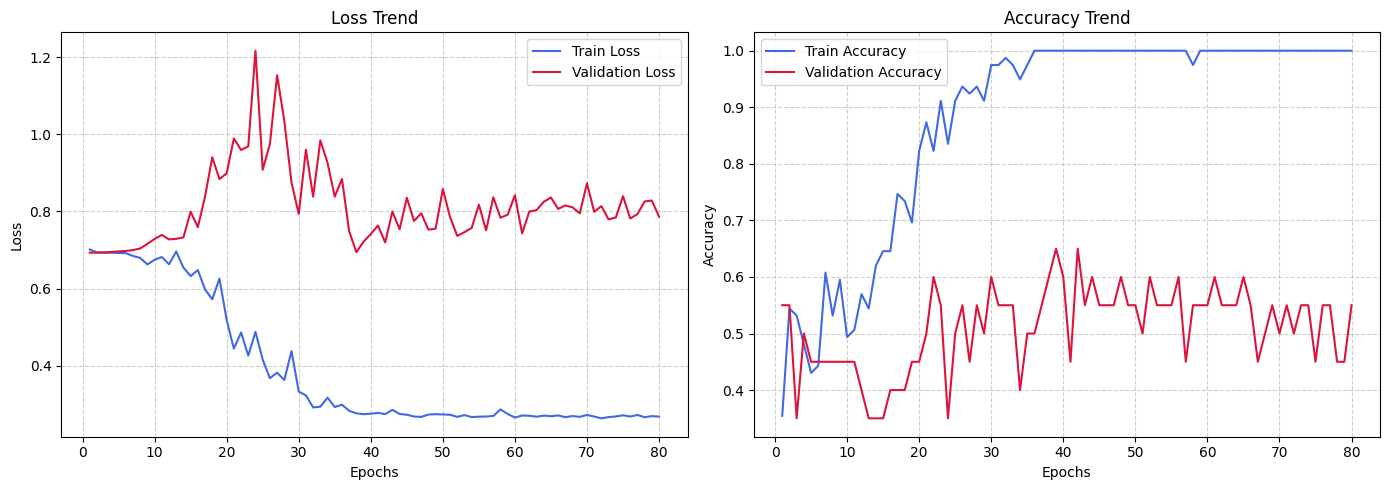

In [6]:
HistoryPlotter().show(history)

Val Loss=0.7416  Acc=0.6000  F1(default)=0.6000  F1(thr=0.200)=0.7151  BAcc=0.7222
Recall rendah=0.4444 | Recall tinggi=1.0000
                precision    recall  f1-score   support

Anxiety Rendah       1.00      0.44      0.62         9
Anxiety Tinggi       0.69      1.00      0.81        11

      accuracy                           0.75        20
     macro avg       0.84      0.72      0.72        20
  weighted avg       0.83      0.75      0.73        20



,precision,recall,f1-score,support
Anxiety Rendah,1.0000,0.4444,0.6154,9.0000
Anxiety Tinggi,0.6875,1.0000,0.8148,11.0000
accuracy,0.7500,0.7500,0.7500,0.7500
macro avg,0.8438,0.7222,0.7151,20.0000
weighted avg,0.8281,0.7500,0.7251,20.0000


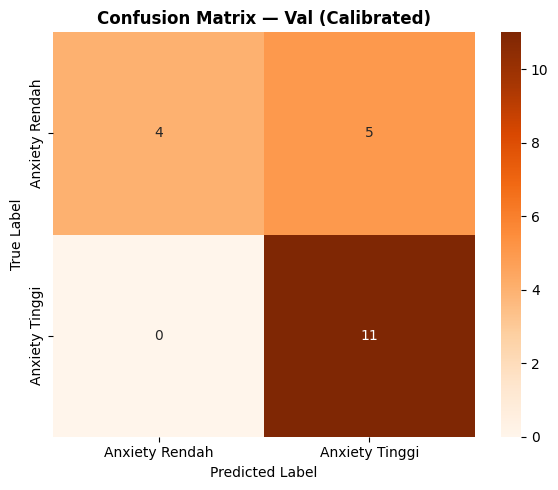

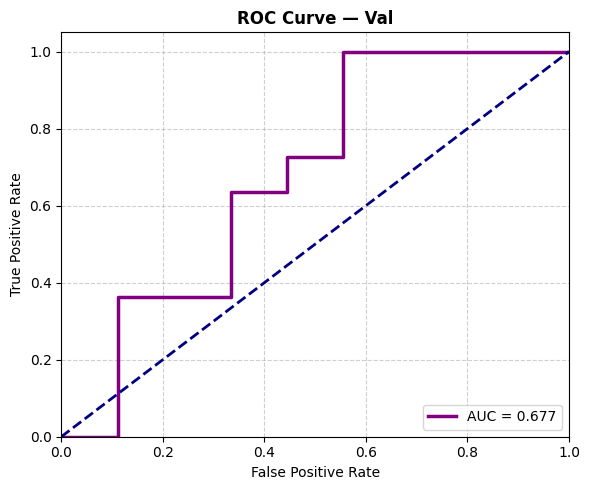

In [7]:
val_loss, val_acc, y_true, y_pred, y_prob = evaluate_model(
    model, val_loader, criterion, threshold=0.5
)
y_true = np.asarray(y_true, dtype=int)
y_prob = np.asarray(y_prob, dtype=float)
y_pred_cal = (y_prob >= best_threshold).astype(int)
val_f1_default = f1_score(y_true, y_pred, average="macro", zero_division=0)
val_f1_cal = f1_score(y_true, y_pred_cal, average="macro", zero_division=0)
val_bacc_cal = balanced_accuracy_score(y_true, y_pred_cal)
rec_rendah = recall_score(y_true, y_pred_cal, pos_label=0, zero_division=0)
rec_tinggi = recall_score(y_true, y_pred_cal, pos_label=1, zero_division=0)
print(
    f"Val Loss={val_loss:.4f}  Acc={val_acc:.4f}  F1(default)={val_f1_default:.4f}  F1(thr={best_threshold:.3f})={val_f1_cal:.4f}  BAcc={val_bacc_cal:.4f}"
)
print(f"Recall rendah={rec_rendah:.4f} | Recall tinggi={rec_tinggi:.4f}")
print(
    classification_report(
        y_true, y_pred_cal, target_names=TARGET_NAMES, zero_division=0
    )
)
ClassificationReportDisplay(target_names=TARGET_NAMES).show(
    y_true, y_pred_cal, loss=val_loss, acc=val_acc
)
ConfusionMatrixPlotter(target_names=TARGET_NAMES).show(
    y_true, y_pred_cal, title="Confusion Matrix — Val (Calibrated)"
)
ROCCurvePlotter().show(y_true, y_prob, title="ROC Curve — Val")



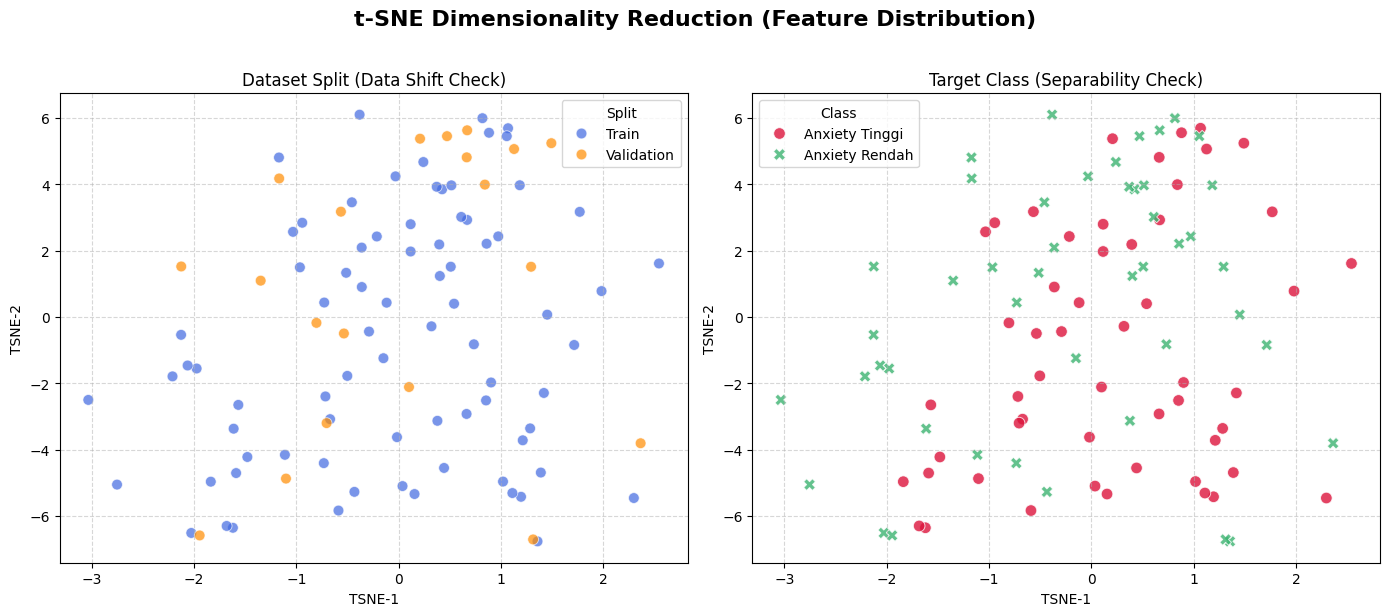

[Diagnostics] calibrated_f1=0.7151 | bacc=0.7222
[Diagnostics] mean|P-0.5|=0.2366 | uncertain%=15.0%


In [8]:
extractor = FeatureExtractor(device=DEVICE)
train_feats, train_lbls = extractor.extract(model, train_loader_clean)
val_feats, val_lbls = extractor.extract(model, val_loader)
TSNEPlotter(target_names=TARGET_NAMES).show(
    train_feats, train_lbls, val_feats, val_lbls
)

val_probs_arr = np.asarray(best_val_y_prob, dtype=float)
val_pred_cal = (val_probs_arr >= best_threshold).astype(int)
val_true_arr = np.asarray(best_val_y_true, dtype=int)
confidence_margin = float(np.mean(np.abs(val_probs_arr - 0.5)))
uncertain_pct = float(np.mean((val_probs_arr > 0.4) & (val_probs_arr < 0.6)) * 100)
print(
    f"[Diagnostics] calibrated_f1={f1_score(val_true_arr, val_pred_cal, average='macro', zero_division=0):.4f} | bacc={balanced_accuracy_score(val_true_arr, val_pred_cal):.4f}"
)
print(
    f"[Diagnostics] mean|P-0.5|={confidence_margin:.4f} | uncertain%={uncertain_pct:.1f}%"
)



In [9]:
ckpt_path = CHECKPOINT_DIR / "best_model.pt"
torch.save(
    {
        "model_state_dict": best_model_state,
        "optimizer_state_dict": optimizer.state_dict(),
        "training_summary": training_summary,
        "best_epoch": int(best_epoch),
        "best_ema_val_f1": float(best_ema_val_f1),
        "best_val_f1": float(best_val_f1),
        "best_val_bacc": float(best_val_bacc),
        "best_val_loss": float(best_val_loss),
        "best_val_acc": float(best_val_acc),
        "best_threshold": float(best_threshold),
        "split_metrics": split_metrics,
        "history": history,
        "n_tta": int(N_TTA),
    },
    ckpt_path,
)
print(f"Saved → {ckpt_path}")



Saved → checkpoints_0405-onset-apex-behavior-cnn-bi-lstm-mha/best_model.pt


In [10]:
LABEL_MAP = {"anxiety_rendah": 0, "anxiety_tinggi": 1}


def run_test_inference(
    annotation_path, output_tag, label_map=LABEL_MAP, threshold=None, title=None
):
    annotation_path = Path(annotation_path)
    if not annotation_path.exists():
        print(f"[Skip] Anotasi tidak ditemukan: {annotation_path}")
        return

    df_test = pd.read_csv(annotation_path)
    if "npy_path" not in df_test.columns and "cache_path" in df_test.columns:
        df_test["npy_path"] = df_test["cache_path"]
    if "is_valid" in df_test.columns:
        df_test = df_test[df_test["is_valid"]].copy()
    df_test = df_test[df_test["label"].isin(label_map)].copy()
    df_test["label_idx"] = df_test["label"].map(label_map)
    print(f"[Test] {len(df_test)} clips, {df_test['subject_id'].nunique()} subjects")

    feature_transform = BehavioralFeatures()
    detector = ApexWindowDetector(
        percentile=DETECTOR_PERCENTILE,
        prominence=DETECTOR_PROMINENCE,
        max_window=MAX_SEQ_LEN,
    )
    eval_transform = Compose(
        [
            WindowSelector(phase_includes=PHASES),
            feature_transform,
            PadAndMask(max_len=MAX_SEQ_LEN),
            AugmentFlow(training=False),
            # ChannelZScore(),
        ]
    )

    def _collate_fn(batch):
        xs = torch.stack([item.x for item in batch])
        ys = torch.stack([item.y for item in batch])
        masks = (
            torch.stack([item.mask for item in batch])
            if batch[0].mask is not None
            else torch.zeros(len(batch), xs.shape[-1], dtype=torch.bool)
        )
        return xs, ys, masks

    inf_model = CNN_BiLSTM_MHA(in_channels=feature_transform.n_channels, hidden_size=64, num_heads=4, num_classes=2).to(DEVICE)

    ds = FlowROIDataset(
        metadata_df=df_test,
        detector=detector,
        phase_mode="full",
        transform=eval_transform,
    )
    loader = DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        collate_fn=_collate_fn,
    )

    ckpt_path = CHECKPOINT_DIR / "best_model.pt"
    if not ckpt_path.exists():
        print(f"[Skip] Checkpoint tidak ditemukan: {ckpt_path}")
        return

    ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    inf_model.load_state_dict(ck["model_state_dict"])
    inf_model.eval()
    if threshold is not None:
        best_thr = float(threshold)
    else:
        best_thr = float(ck.get("best_threshold", 0.5))
    print(f"[Checkpoint] best_threshold={best_thr:.3f}")

    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc, y_true_t, y_pred_t, y_prob_t = evaluate_model(
        inf_model,
        loader,
        criterion,
        threshold=best_thr,
        use_tta=bool(globals().get("USE_TTA_INFERENCE", True)),
        n_tta=ck.get("n_tta", globals().get("N_TTA", 8)),
    )

    f1_macro = float(f1_score(y_true_t, y_pred_t, average="macro", zero_division=0))
    f1_w = float(f1_score(y_true_t, y_pred_t, average="weighted", zero_division=0))
    bacc = float(balanced_accuracy_score(y_true_t, y_pred_t))
    rec_rd = float(recall_score(y_true_t, y_pred_t, pos_label=0, zero_division=0))
    rec_tg = float(recall_score(y_true_t, y_pred_t, pos_label=1, zero_division=0))

    display_name = title or annotation_path.name
    print(f"\n{'=' * 60}")
    print(f"[Test Inference — {display_name}]")
    print(f"{'=' * 60}")
    print(f"  Test Loss        : {test_loss:.4f}")
    print(f"  Test Acc         : {test_acc:.4f}")
    print(f"  Macro F1         : {f1_macro:.4f}")
    print(f"  Weighted F1      : {f1_w:.4f}")
    print(f"  Balanced Acc     : {bacc:.4f}")
    print(f"  Recall rendah    : {rec_rd:.4f}")
    print(f"  Recall tinggi    : {rec_tg:.4f}")
    print()
    print(
        classification_report(
            y_true_t, y_pred_t, target_names=TARGET_NAMES, zero_division=0
        )
    )

    ClassificationReportDisplay(target_names=TARGET_NAMES).show(
        y_true_t, y_pred_t, loss=test_loss, acc=test_acc
    )
    ConfusionMatrixPlotter(target_names=TARGET_NAMES).show(
        y_true_t, y_pred_t, title=f"Confusion Matrix — {display_name}"
    )
    ROCCurvePlotter().show(y_true_t, y_prob_t, title=f"ROC Curve — {display_name}")

    metrics = {
        "annotation_test": str(annotation_path),
        "n_clips": len(df_test),
        "n_subjects": int(df_test["subject_id"].nunique()),
        "test_loss": float(test_loss),
        "test_acc": float(test_acc),
        "test_f1_macro": f1_macro,
        "test_f1_weighted": f1_w,
        "test_bacc": bacc,
        "test_recall_rendah": rec_rd,
        "test_recall_tinggi": rec_tg,
        "best_threshold": best_thr,
    }
    metrics_path = CHECKPOINT_DIR / f"{output_tag}.json"
    with open(metrics_path, "w") as fp:
        json.dump(metrics, fp, indent=2, default=float)
    print(f"[Saved] {metrics_path}")

    rows = []
    for yt, yp, ypr in zip(y_true_t, y_pred_t, y_prob_t):
        rows.append(
            {
                "true_label": int(yt),
                "true_class": TARGET_NAMES[int(yt)],
                "predicted_label": TARGET_NAMES[int(yp)],
                "prob_tinggi": float(ypr),
                "prob_rendah": float(1 - ypr),
            }
        )
    df_res = pd.DataFrame(rows)
    csv_path = CHECKPOINT_DIR / f"{output_tag}.csv"
    df_res.to_csv(csv_path, index=False)
    print(f"[Saved] {csv_path} ({len(df_res)} samples)")




[Test] 499 clips, 102 subjects
[Checkpoint] best_threshold=0.200

[Test Inference — clips-annotations-v10.csv]
  Test Loss        : 1.0167
  Test Acc         : 0.5980
  Macro F1         : 0.5112
  Weighted F1      : 0.6081
  Balanced Acc     : 0.5133
  Recall rendah    : 0.3333
  Recall tinggi    : 0.6933

                precision    recall  f1-score   support

Anxiety Rendah       0.28      0.33      0.31        27
Anxiety Tinggi       0.74      0.69      0.72        75

      accuracy                           0.60       102
     macro avg       0.51      0.51      0.51       102
  weighted avg       0.62      0.60      0.61       102



,precision,recall,f1-score,support
Anxiety Rendah,0.2812,0.3333,0.3051,27.0000
Anxiety Tinggi,0.7429,0.6933,0.7172,75.0000
accuracy,0.5980,0.5980,0.5980,0.5980
macro avg,0.5121,0.5133,0.5112,102.0000
weighted avg,0.6207,0.5980,0.6081,102.0000


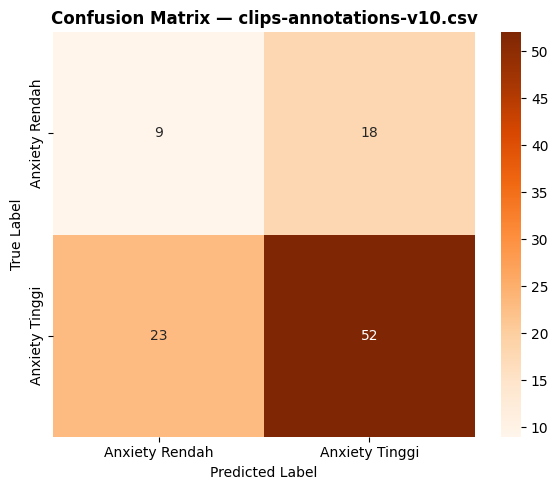

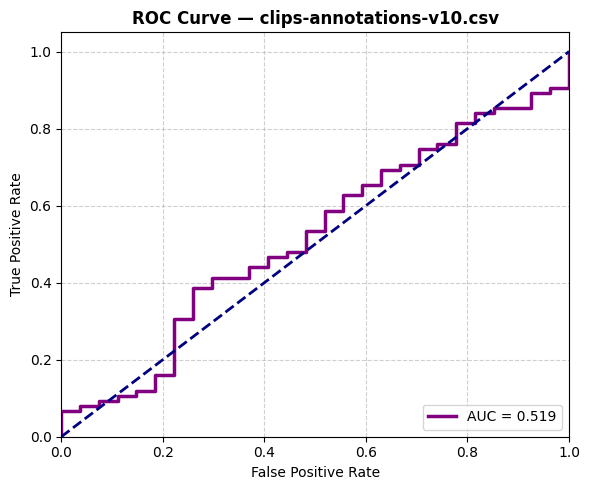

[Saved] checkpoints_0405-onset-apex-behavior-cnn-bi-lstm-mha/test_results.json
[Saved] checkpoints_0405-onset-apex-behavior-cnn-bi-lstm-mha/test_results.csv (102 samples)


In [11]:
ANNOTATION_TEST = Path("/home/inadio/datasets/dataset_test/clips-annotations-v10.csv")
run_test_inference(ANNOTATION_TEST, output_tag="test_results")

[Test] 261 clips, 57 subjects
[Checkpoint] best_threshold=0.200


[achmad_syah_wildan_rosid_1778125912139] Gagal load /home/inadio/datasets/dataset_test_2/.cache-v10/achmad_syah_wildan_rosid_1778125912139_q2.npz: Flow ROI harus (T, N_roi, 2, H, W), got ()
[charles_ardiansya_wicaksono_1778126307159] Gagal load /home/inadio/datasets/dataset_test_2/.cache-v10/charles_ardiansya_wicaksono_1778126307159_q4.npz: Flow ROI harus (T, N_roi, 2, H, W), got ()
[david_eka_prastya_1778126135913] Gagal load /home/inadio/datasets/dataset_test_2/.cache-v10/david_eka_prastya_1778126135913_q4.npz: Flow ROI harus (T, N_roi, 2, H, W), got ()
[faiqoh_akmalina_1778126292558] Gagal load /home/inadio/datasets/dataset_test_2/.cache-v10/faiqoh_akmalina_1778126292558_q1.npz: Flow ROI harus (T, N_roi, 2, H, W), got ()
[farid_andi_wijaya_1778126736019] Gagal load /home/inadio/datasets/dataset_test_2/.cache-v10/farid_andi_wijaya_1778126736019_q4.npz: Flow ROI harus (T, N_roi, 2, H, W), got ()
[farid_andi_wijaya_1778127705564] Gagal load /home/inadio/datasets/dataset_test_2/.cache-v


[Test Inference — annotations-clips-v10.csv]
  Test Loss        : 0.9192
  Test Acc         : 0.7544
  Macro F1         : 0.5382
  Weighted F1      : 0.7987
  Balanced Acc     : 0.5942
  Recall rendah    : 0.4000
  Recall tinggi    : 0.7885

                precision    recall  f1-score   support

Anxiety Rendah       0.15      0.40      0.22         5
Anxiety Tinggi       0.93      0.79      0.85        52

      accuracy                           0.75        57
     macro avg       0.54      0.59      0.54        57
  weighted avg       0.86      0.75      0.80        57



,precision,recall,f1-score,support
Anxiety Rendah,0.1538,0.4000,0.2222,5.0000
Anxiety Tinggi,0.9318,0.7885,0.8542,52.0000
accuracy,0.7544,0.7544,0.7544,0.7544
macro avg,0.5428,0.5942,0.5382,57.0000
weighted avg,0.8636,0.7544,0.7987,57.0000


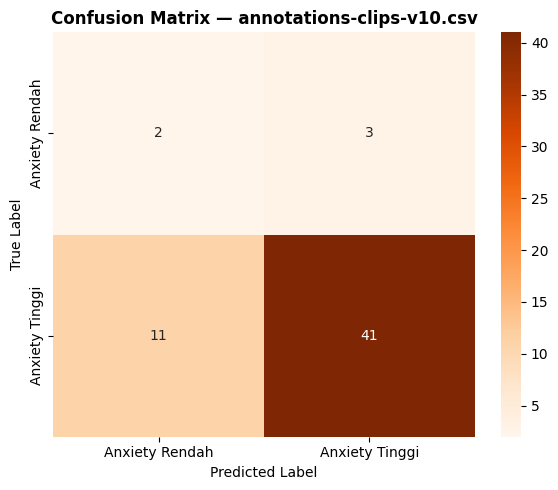

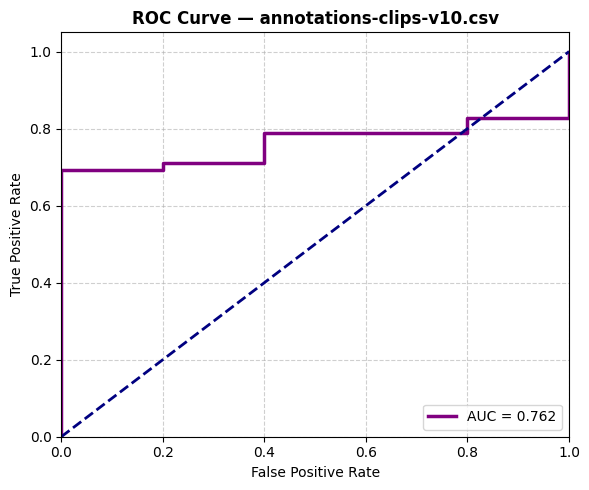

[Saved] checkpoints_0405-onset-apex-behavior-cnn-bi-lstm-mha/test_results.json
[Saved] checkpoints_0405-onset-apex-behavior-cnn-bi-lstm-mha/test_results.csv (57 samples)


In [12]:
ANNOTATION_TEST_2 = Path(
    "/home/inadio/datasets/dataset_test_2/annotations-clips-v10.csv"
)
run_test_inference(ANNOTATION_TEST_2, output_tag="test_results")